# ✋ Hands-On: Build a Hand Gesture Recogniser

So far, we have seen how Computer Vision can identify important structures in an image using **keypoints and landmarks**.

Now, we will use these hand landmarks to build a system that can recognise different hand gestures.

## 0. Setup

Run the following cells to set up the environment. You do not need to modify the code in this section.

### 0.1 Install dependencies

In [1]:
# !pip install -q mediapipe pandas scikit-learn matplotlib opencv-python

### 0.2 Import Libraries

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    ConfusionMatrixDisplay
)
from pathlib import Path
from urllib.request import urlretrieve

import mediapipe as mp
import mediapipe.tasks as tasks

print("MediaPipe version:", mp.__version__)
print("Setup successful!")

MediaPipe version: 1.0.1
Setup successful!


### 0.3 Download MediaPipe model

This is a pretrained MediaPipe Hand Landmarker model itself.

In [3]:
MODEL_PATH = Path("hand_landmarker.task")

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/latest/"
    "hand_landmarker.task"
)

if not MODEL_PATH.exists():
    print("Downloading MediaPipe Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

print("Model ready:", MODEL_PATH.exists())

Model ready: True


## 1. What Are We Building? ✋

We have seen how Computer Vision can identify important structures in an image using **keypoints and landmarks**.

For our hands-on, we will use these hand landmarks to build a system that can recognise different hand gestures.

Our goal is to answer:

> **Given an unseen image of a hand, can our system recognise the gesture being shown?**

### 1.1 Our Computer Vision Pipeline

Our gesture recognition system will follow this pipeline:

**Hand Image**  
↓  
**MediaPipe Hand Landmarker**  
↓  
**21 Hand Landmarks**  
↓  
**Landmark Features**  
↓  
**Gesture Classifier**  
↓  
**Gesture Prediction**

MediaPipe acts as our **pretrained Computer Vision model**, transforming the raw hand image into a structured representation of the hand.

We will then use this representation to recognise different hand gestures.

### 1.2 Your Task

Some parts of the pipeline have already been prepared so that we can focus on understanding and building the gesture recognition system.

### Provided for you

- Pretrained MediaPipe Hand Landmarker
- Hand landmark extraction setup
- Prepared gesture data
- Visualisation/helper code

### You will

1. 👀 **Explore** how a hand is represented using landmarks
2. 🧩 **Construct features** from the landmark coordinates
3. 🌲 **Train** a gesture classifier
4. 📊 **Evaluate** how well it performs
5. 🖼️ **Test** the complete pipeline on unseen hand images
6. 🔍 **Investigate** where incorrect predictions come from

### 1.3 Gestures We Will Recognise

Our initial system will recognise four gestures:

| Gesture | Label |
|---|---|
| ✋ Open Palm | `OPEN_PALM` |
| ✊ Fist | `FIST` |
| ✌️ Peace | `PEACE` |
| ☝️ Pointing | `POINTING` |

Later, we will test whether our system can recognise these gestures in images it has **not seen before**.

## 2. Explore the Hand Landmark Representation

Before training our gesture recogniser, let's first understand the visual information provided by MediaPipe.

We will start with a hand image and use the pretrained **MediaPipe Hand Landmarker** to extract its 21 landmarks.

### 2.1 Start with a Hand Image

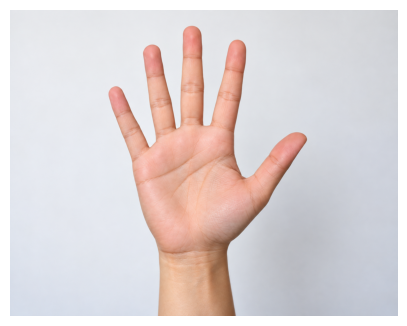

In [5]:
IMAGE_PATH = "../data/workshop images/open_palm.png"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

# OpenCV loads images in BGR format.
# Convert it to RGB for display.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

### 2.2 Image -> MediaPipe -> Landmarks

For gesture recognition, we are particularly interested in the **structure of the hand**:

- Where is the wrist?
- Where are the finger joints?
- Where are the fingertips?

MediaPipe Hand Landmarker is a pretrained Computer Vision model that represents a detected hand using **21 landmarks**.

In [6]:
# Configure MediaPipe Hand Landmarker

MODEL_PATH = "hand_landmarker.task"

base_options = tasks.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = tasks.vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

landmarker = tasks.vision.HandLandmarker.create_from_options(
    options
)

In [7]:
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

result = landmarker.detect(mp_image)

print("Hands detected:", len(result.hand_landmarks))

Hands detected: 1


In [8]:
if result.hand_landmarks:
    hand_landmarks = result.hand_landmarks[0]

    print("Number of landmarks:", len(hand_landmarks))
else:
    raise ValueError("No hand detected in the image.")

Number of landmarks: 21


### 2.3 Visualise the 21 Landmarks

In [9]:
HAND_CONNECTIONS = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),

    # Index finger
    (0, 5), (5, 6), (6, 7), (7, 8),

    # Middle finger
    (5, 9), (9, 10), (10, 11), (11, 12),

    # Ring finger
    (9, 13), (13, 14), (14, 15), (15, 16),

    # Pinky
    (13, 17), (17, 18), (18, 19), (19, 20),

    # Palm
    (0, 17),
]

In [10]:
def draw_hand_landmarks(image, hand_landmarks):
    output = image.copy()

    height, width, _ = output.shape
    points = []

    # Convert normalized coordinates to pixel coordinates
    for landmark in hand_landmarks:
        x = int(landmark.x * width)
        y = int(landmark.y * height)
        points.append((x, y))

    # Draw connections
    for start, end in HAND_CONNECTIONS:
        cv2.line(
            output,
            points[start],
            points[end],
            (255, 255, 255),
            2
        )

    # Draw landmarks
    for index, point in enumerate(points):
        cv2.circle(
            output,
            point,
            5,
            (0, 255, 0),
            -1
        )

        cv2.putText(
            output,
            str(index),
            (point[0] + 5, point[1] - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (0, 255, 0),
            1
        )

    return output

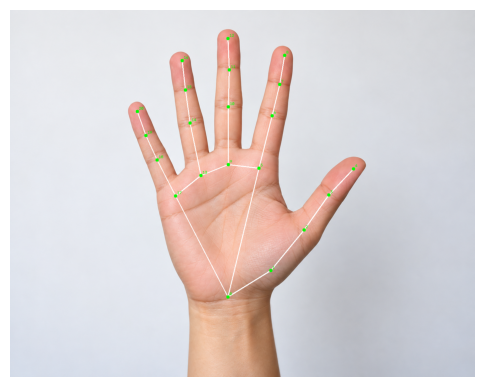

In [11]:
landmark_image = draw_hand_landmarks(
    image_rgb,
    hand_landmarks
)

plt.figure(figsize=(6, 6))
plt.imshow(landmark_image)
plt.axis("off")
plt.show()

### 2.4 What do the landmarks represent?

Each landmark corresponds to a specific part of the hand.

Some useful examples are:

| Landmark | Hand Part |
|---|---|
| `0` | Wrist |
| `4` | Thumb tip |
| `8` | Index fingertip |
| `12` | Middle fingertip |
| `16` | Ring fingertip |
| `20` | Pinky fingertip |

You do **not** need to memorise all 21 landmark numbers!

### 2.5 Inspect the Coordinates

Each landmark contains three normalized coordinates:

- **x** — horizontal position
- **y** — vertical position
- **z** — relative depth

Let's inspect the index fingertip (`landmark 8`).

In [12]:
index_tip = hand_landmarks[8]

print("Index fingertip (Landmark 8)")
print(f"x = {index_tip.x:.3f}")
print(f"y = {index_tip.y:.3f}")
print(f"z = {index_tip.z:.3f}")

Index fingertip (Landmark 8)
x = 0.591
y = 0.126
z = -0.134


### 🔍 Your Turn

Landmark `12` represents the **middle fingertip**.

Can you inspect its `(x, y, z)` coordinates?

In [13]:
# Replace ____ with the correct landmark number

# middle_tip = hand_landmarks[____]
middle_tip = hand_landmarks[12]

print(f"x = {middle_tip.x:.3f}")
print(f"y = {middle_tip.y:.3f}")
print(f"z = {middle_tip.z:.3f}")

x = 0.468
y = 0.080
z = -0.137


### 2.7 What Have We Done?

We started with:

**Raw Image**

and transformed it into:

**21 structured hand landmarks**

Instead of reasoning directly over every pixel in the image, we now have a compact representation describing the **structure and geometry of the hand**.

Next, we will turn these landmarks into features that can be used to recognise different gestures.

## 3. From Landmarks to Gesture Features

We now have **21 landmarks** describing the structure of the hand.

Each landmark contains three coordinates:

- `x`
- `y`
- `z`

This gives us:

**21 landmarks × 3 coordinates = 63 values**

These values can be used to describe the hand's structure and eventually help us distinguish between different gestures.

### 3.1 A Problem With Raw Coordinates

Consider showing the same ✌️ gesture at two different positions in the image.

The gesture has not changed, but the landmark coordinates will be different because the hand has moved.

For example:

**Left side of image** → smaller `x` coordinates  
**Right side of image** → larger `x` coordinates

Should our gesture recogniser consider these to be different gestures?

### 3.2 Look at the raw coordinates

In [15]:
# Let's inspect the first few raw landmark coordinates

for i in range(5):
    landmark = hand_landmarks[i]

    print(
        f"Landmark {i}: "
        f"x={landmark.x:.3f}, "
        f"y={landmark.y:.3f}, "
        f"z={landmark.z:.3f}"
    )

Landmark 0: x=0.469, y=0.783, z=0.000
Landmark 1: x=0.561, y=0.711, z=-0.059
Landmark 2: x=0.632, y=0.600, z=-0.082
Landmark 3: x=0.686, y=0.505, z=-0.100
Landmark 4: x=0.739, y=0.435, z=-0.118


### 3.3 Use the wrist as our reference point

Instead of describing every landmark relative to the entire image,
we can describe each landmark relative to the **wrist**.

MediaPipe uses landmark `0` for the wrist.

For every landmark:

$x_{relative} = x_{landmark} - x_{wrist}$

$y_{relative} = y_{landmark} - y_{wrist}$

$z_{relative} = z_{landmark} - z_{wrist}$

This shifts the hand representation so that the wrist becomes our reference point.

### 💻 Your Turn: Create Wrist-Relative Features

Complete the function below so that every landmark is represented relative to the wrist.

In [16]:
def create_features(hand_landmarks):

    wrist = hand_landmarks[0]
    features = []

    for landmark in hand_landmarks:

        # # TODO: Make each coordinate relative to the wrist
        # relative_x = landmark.x - ________
        # relative_y = landmark.y - ________
        # relative_z = landmark.z - ________

         # SOLUTION
        relative_x = landmark.x - wrist.x
        relative_y = landmark.y - wrist.y
        relative_z = landmark.z - wrist.z

        features.extend([
            relative_x,
            relative_y,
            relative_z
        ])

    return features

💡 **Hint:** `wrist.x`, `wrist.y` and `wrist.z` contain the coordinates of landmark `0`.

### 3.4 Create the feature vector

In [20]:
features = create_features(hand_landmarks)

print("Number of features:", len(features))

print("First 12 features:")
# The first 12 values represent the first 4 landmarks (0, 1, 2, 3),
# with 3 coordinates (x, y, z) for each landmark.

for value in features[:12]:
    print(f"{value:.3f}")

Number of features: 63
First 12 features:
0.000
0.000
0.000
0.092
-0.072
-0.059
0.164
-0.182
-0.082
0.217
-0.277
-0.100


### 3.5 A Quick Check

Since all landmarks are now represented relative to the wrist, what should the wrist's own coordinates become?

Remember:

$x_{relative} = x_{landmark} - x_{wrist}$

For landmark `0`, the landmark itself **is the wrist**.

In [21]:
print("Wrist features:")
print(features[:3])

Wrist features:
[0.0, 0.0, 0.0]


## 4. Meet the Gesture Dataset

So far, we have transformed **one hand image** into 63 landmark features.

To teach a model to recognise gestures, we need many examples of different gestures.

Our dataset was created using the same process:

**Hand Image / Webcam Frame**  
↓  
**MediaPipe Hand Landmarker**  
↓  
**21 Hand Landmarks**  
↓  
**Wrist-Relative Coordinates**  
↓  
**63 Features + Gesture Label**

### 4.1 What Does One Row Represent?

Each row in our dataset represents **one detected hand**.

The columns contain:

- `x0, y0, z0` → Landmark 0
- `x1, y1, z1` → Landmark 1
- ...
- `x20, y20, z20` → Landmark 20
- `label` → The gesture being shown

This gives us:

**63 landmark features + 1 gesture label**